In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings("ignore")

In [4]:
app = pd.read_csv("../dataset/application_record.csv")
credit = pd.read_csv("../dataset/credit_record.csv")

In [5]:
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [7]:
print("Application Dataset Shape:", app.shape)
print("Credit Dataset Shape:", credit.shape)

Application Dataset Shape: (438557, 18)
Credit Dataset Shape: (1048575, 3)


In [8]:
app.info()

<class 'pandas.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  str    
 2   FLAG_OWN_CAR         438557 non-null  str    
 3   FLAG_OWN_REALTY      438557 non-null  str    
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  str    
 7   NAME_EDUCATION_TYPE  438557 non-null  str    
 8   NAME_FAMILY_STATUS   438557 non-null  str    
 9   NAME_HOUSING_TYPE    438557 non-null  str    
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL           438557 

In [9]:
credit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype
---  ------          --------------    -----
 0   ID              1048575 non-null  int64
 1   MONTHS_BALANCE  1048575 non-null  int64
 2   STATUS          1048575 non-null  str  
dtypes: int64(2), str(1)
memory usage: 24.0 MB


In [10]:
app.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [11]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [12]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [13]:
print("Application Duplicates:", app.duplicated().sum())
print("Credit Duplicates:", credit.duplicated().sum())

Application Duplicates: 0
Credit Duplicates: 0


print("Number of people by Occupation:\n")
print(app['OCCUPATION_TYPE'].value_counts())

plt.figure(figsize=(18,6))
sns.countplot(x='OCCUPATION_TYPE', data=app, palette='Set2')
plt.xticks(rotation=90)
plt.title("Occupation Type Distribution")
plt.show()

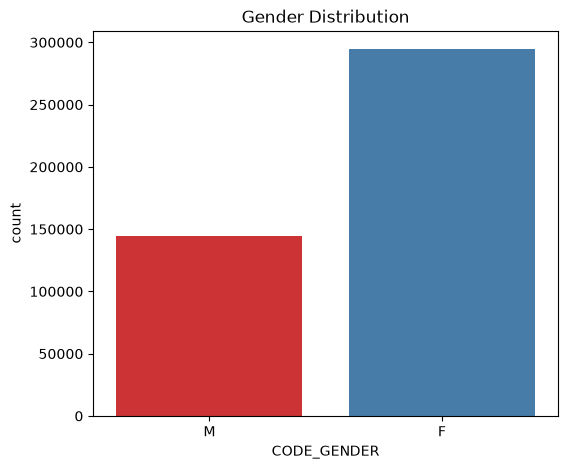

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(x='CODE_GENDER', data=app, palette='Set1')
plt.title("Gender Distribution")
plt.show()

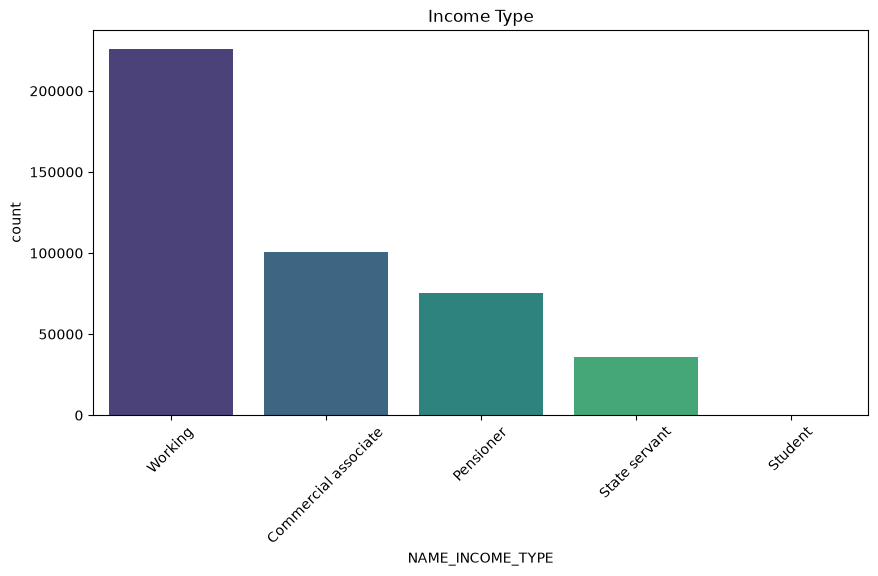

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x='NAME_INCOME_TYPE', data=app, palette='viridis')
plt.xticks(rotation=45)
plt.title("Income Type")
plt.show()

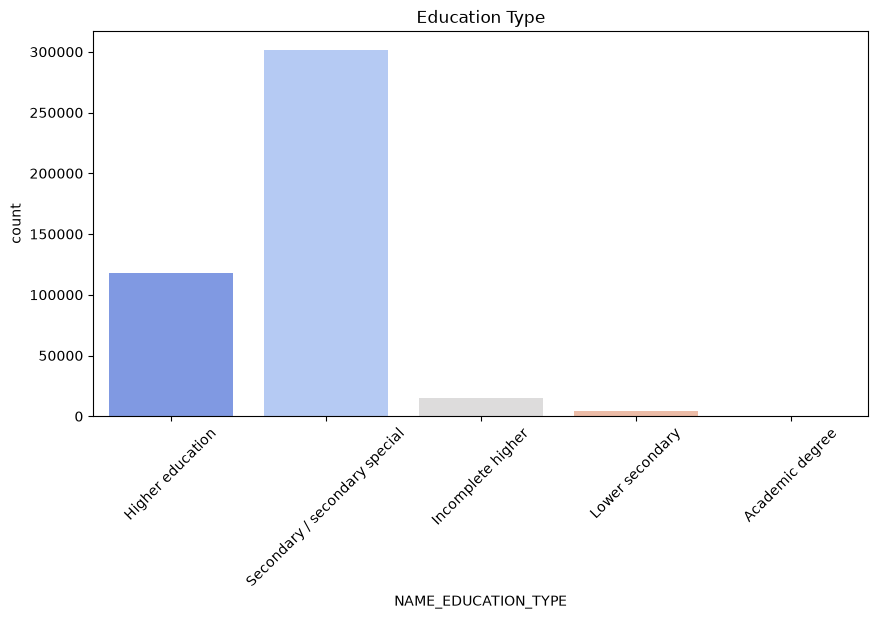

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='NAME_EDUCATION_TYPE', data=app, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Education Type")
plt.show()

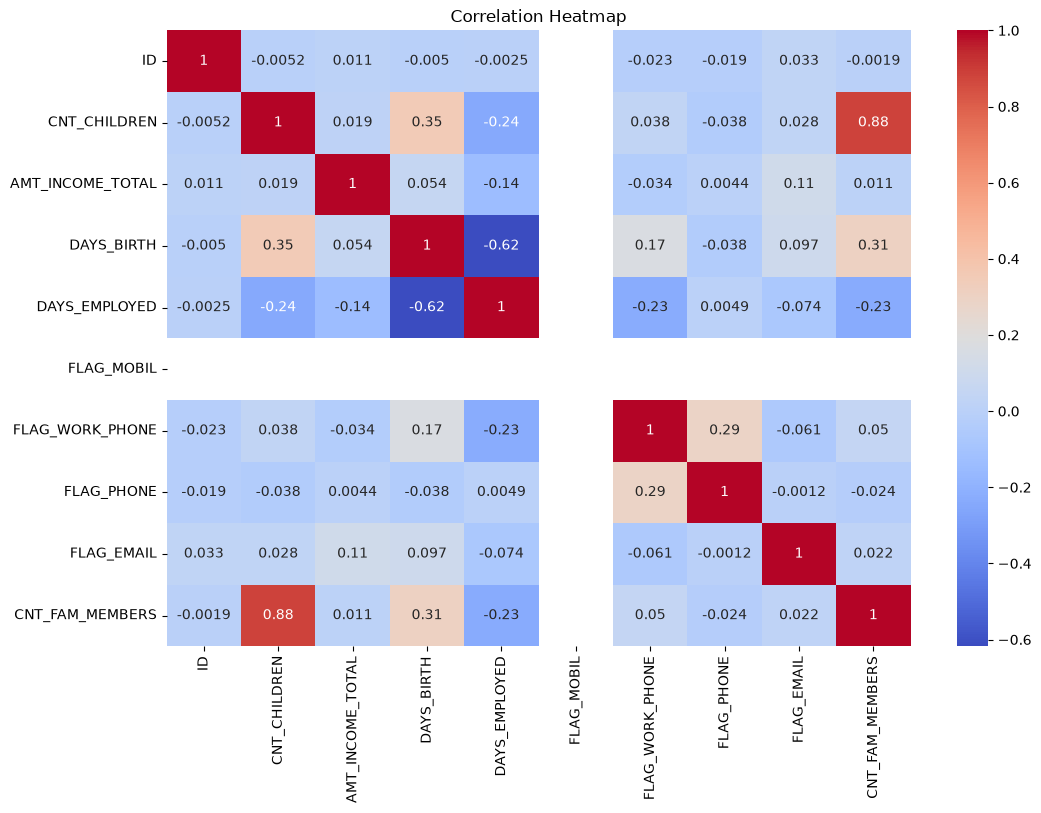

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(app.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
app.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [19]:
print("Before:", app.shape)

app.drop_duplicates(inplace=True)

print("After:", app.shape)

Before: (438557, 18)
After: (438557, 18)


In [20]:
app.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [21]:
app.isnull().mean()

ID                     0.00000
CODE_GENDER            0.00000
FLAG_OWN_CAR           0.00000
FLAG_OWN_REALTY        0.00000
CNT_CHILDREN           0.00000
AMT_INCOME_TOTAL       0.00000
NAME_INCOME_TYPE       0.00000
NAME_EDUCATION_TYPE    0.00000
NAME_FAMILY_STATUS     0.00000
NAME_HOUSING_TYPE      0.00000
DAYS_BIRTH             0.00000
DAYS_EMPLOYED          0.00000
FLAG_MOBIL             0.00000
FLAG_WORK_PHONE        0.00000
FLAG_PHONE             0.00000
FLAG_EMAIL             0.00000
OCCUPATION_TYPE        0.30601
CNT_FAM_MEMBERS        0.00000
dtype: float64

In [22]:
# Convert negative values into positive values
app['DAYS_BIRTH'] = app['DAYS_BIRTH'].abs()
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].abs()

# Display first few rows
app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,12005,4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,21474,1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,19110,3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,19110,3051,1,0,1,1,Sales staff,1.0


In [23]:
# Convert STATUS into Binary Values

def to_binary(status):
    if status in ['0', 'X', 'C']:
        return 1      # Approved
    else:
        return 0      # Not Approved

credit['STATUS_BIN'] = credit['STATUS'].apply(to_binary)

credit[['STATUS', 'STATUS_BIN']].head()

,STATUS,STATUS_BIN
0,X,1
1,0,1
2,0,1
3,0,1
4,C,1


In [24]:
credit['STATUS_BIN'].value_counts()

STATUS_BIN
1    1034381
0      14194
Name: count, dtype: int64

In [25]:
credit_app = pd.merge(app, credit, on='ID', how='left')

print("Merged Dataset Shape:", credit_app.shape)

Merged Dataset Shape: (1179815, 21)


In [26]:
credit_app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,STATUS_BIN
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542,1,1,0,0,NaN,2.0,0.0,C,1.0
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542,1,1,0,0,NaN,2.0,-1.0,C,1.0
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542,1,1,0,0,NaN,2.0,-2.0,C,1.0
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542,1,1,0,0,NaN,2.0,-3.0,C,1.0
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,4542,1,1,0,0,NaN,2.0,-4.0,C,1.0


In [27]:
credit_app.info()

<class 'pandas.DataFrame'>
RangeIndex: 1179815 entries, 0 to 1179814
Data columns (total 21 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   ID                   1179815 non-null  int64  
 1   CODE_GENDER          1179815 non-null  str    
 2   FLAG_OWN_CAR         1179815 non-null  str    
 3   FLAG_OWN_REALTY      1179815 non-null  str    
 4   CNT_CHILDREN         1179815 non-null  int64  
 5   AMT_INCOME_TOTAL     1179815 non-null  float64
 6   NAME_INCOME_TYPE     1179815 non-null  str    
 7   NAME_EDUCATION_TYPE  1179815 non-null  str    
 8   NAME_FAMILY_STATUS   1179815 non-null  str    
 9   NAME_HOUSING_TYPE    1179815 non-null  str    
 10  DAYS_BIRTH           1179815 non-null  int64  
 11  DAYS_EMPLOYED        1179815 non-null  int64  
 12  FLAG_MOBIL           1179815 non-null  int64  
 13  FLAG_WORK_PHONE      1179815 non-null  int64  
 14  FLAG_PHONE           1179815 non-null  int64  
 15  FLAG_EMAI

In [28]:
credit_app.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        362928
CNT_FAM_MEMBERS             0
MONTHS_BALANCE         402100
STATUS                 402100
STATUS_BIN             402100
dtype: int64

In [29]:
credit_app.isnull().mean()

ID                     0.000000
CODE_GENDER            0.000000
FLAG_OWN_CAR           0.000000
FLAG_OWN_REALTY        0.000000
CNT_CHILDREN           0.000000
AMT_INCOME_TOTAL       0.000000
NAME_INCOME_TYPE       0.000000
NAME_EDUCATION_TYPE    0.000000
NAME_FAMILY_STATUS     0.000000
NAME_HOUSING_TYPE      0.000000
DAYS_BIRTH             0.000000
DAYS_EMPLOYED          0.000000
FLAG_MOBIL             0.000000
FLAG_WORK_PHONE        0.000000
FLAG_PHONE             0.000000
FLAG_EMAIL             0.000000
OCCUPATION_TYPE        0.307614
CNT_FAM_MEMBERS        0.000000
MONTHS_BALANCE         0.340816
STATUS                 0.340816
STATUS_BIN             0.340816
dtype: float64

In [30]:
credit_app.drop(
    columns=['OCCUPATION_TYPE', 'MONTHS_BALANCE', 'STATUS'],
    inplace=True
)

In [31]:
credit_app.dropna(subset=['STATUS_BIN'], inplace=True)

In [32]:
credit_app.isnull().sum()

ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
CNT_FAM_MEMBERS        0
STATUS_BIN             0
dtype: int64

In [33]:
credit_app.info()

<class 'pandas.DataFrame'>
Index: 777715 entries, 0 to 1176070
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  str    
 2   FLAG_OWN_CAR         777715 non-null  str    
 3   FLAG_OWN_REALTY      777715 non-null  str    
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  str    
 7   NAME_EDUCATION_TYPE  777715 non-null  str    
 8   NAME_FAMILY_STATUS   777715 non-null  str    
 9   NAME_HOUSING_TYPE    777715 non-null  str    
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL           777715 non-

In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
gender = LabelEncoder()
car = LabelEncoder()
reality = LabelEncoder()
income = LabelEncoder()
education = LabelEncoder()
family = LabelEncoder()
housing = LabelEncoder()

In [36]:
credit_app["CODE_GENDER"] = gender.fit_transform(credit_app["CODE_GENDER"])

credit_app["FLAG_OWN_CAR"] = car.fit_transform(credit_app["FLAG_OWN_CAR"])

credit_app["FLAG_OWN_REALTY"] = reality.fit_transform(credit_app["FLAG_OWN_REALTY"])

credit_app["NAME_INCOME_TYPE"] = income.fit_transform(credit_app["NAME_INCOME_TYPE"])

credit_app["NAME_EDUCATION_TYPE"] = education.fit_transform(credit_app["NAME_EDUCATION_TYPE"])

credit_app["NAME_FAMILY_STATUS"] = family.fit_transform(credit_app["NAME_FAMILY_STATUS"])

credit_app["NAME_HOUSING_TYPE"] = housing.fit_transform(credit_app["NAME_HOUSING_TYPE"])

In [37]:
credit_app.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,STATUS_BIN
0,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,1.0
1,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,1.0
2,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,1.0
3,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,1.0
4,5008804,1,1,1,0,427500.0,4,1,0,4,12005,4542,1,1,0,0,2.0,1.0


In [38]:
credit_app.info()

<class 'pandas.DataFrame'>
Index: 777715 entries, 0 to 1176070
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   777715 non-null  int64  
 1   CODE_GENDER          777715 non-null  int64  
 2   FLAG_OWN_CAR         777715 non-null  int64  
 3   FLAG_OWN_REALTY      777715 non-null  int64  
 4   CNT_CHILDREN         777715 non-null  int64  
 5   AMT_INCOME_TOTAL     777715 non-null  float64
 6   NAME_INCOME_TYPE     777715 non-null  int64  
 7   NAME_EDUCATION_TYPE  777715 non-null  int64  
 8   NAME_FAMILY_STATUS   777715 non-null  int64  
 9   NAME_HOUSING_TYPE    777715 non-null  int64  
 10  DAYS_BIRTH           777715 non-null  int64  
 11  DAYS_EMPLOYED        777715 non-null  int64  
 12  FLAG_MOBIL           777715 non-null  int64  
 13  FLAG_WORK_PHONE      777715 non-null  int64  
 14  FLAG_PHONE           777715 non-null  int64  
 15  FLAG_EMAIL           777715 non-

In [39]:
X = credit_app.drop(["STATUS_BIN"], axis=1)
y = credit_app["STATUS_BIN"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (777715, 17)
Target Shape: (777715,)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (622172, 17)
Testing Features  : (155543, 17)
Training Labels   : (622172,)
Testing Labels    : (155543,)


In [41]:
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print()
print(confusion_matrix(y_test, y_pred_lr))
print()
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9853095285548048

[[     0   2285]
 [     0 153258]]

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      2285
         1.0       0.99      1.00      0.99    153258

    accuracy                           0.99    155543
   macro avg       0.49      0.50      0.50    155543
weighted avg       0.97      0.99      0.98    155543



In [42]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print()
print(confusion_matrix(y_test, y_pred_dt))
print()
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9858752885054294

[[   331   1954]
 [   243 153015]]

              precision    recall  f1-score   support

         0.0       0.58      0.14      0.23      2285
         1.0       0.99      1.00      0.99    153258

    accuracy                           0.99    155543
   macro avg       0.78      0.57      0.61    155543
weighted avg       0.98      0.99      0.98    155543



In [43]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()
print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9861131648483056

[[   313   1972]
 [   188 153070]]

              precision    recall  f1-score   support

         0.0       0.62      0.14      0.22      2285
         1.0       0.99      1.00      0.99    153258

    accuracy                           0.99    155543
   macro avg       0.81      0.57      0.61    155543
weighted avg       0.98      0.99      0.98    155543



In [44]:
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print()
print(confusion_matrix(y_test, y_pred_xgb))
print()
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.9857017030660332

[[   109   2176]
 [    48 153210]]

              precision    recall  f1-score   support

         0.0       0.69      0.05      0.09      2285
         1.0       0.99      1.00      0.99    153258

    accuracy                           0.99    155543
   macro avg       0.84      0.52      0.54    155543
weighted avg       0.98      0.99      0.98    155543



In [45]:
model_accuracy = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

for model, acc in model_accuracy.items():
    print(f"{model}: {acc:.4f}")

Logistic Regression: 0.9853
Decision Tree: 0.9859
Random Forest: 0.9861
XGBoost: 0.9857


In [46]:
import joblib

joblib.dump(xgb_model, "../models/model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [47]:
loaded_model = joblib.load("../models/model.pkl")

print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)
